In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("bayesian_stats_course_tools.light")
import scipy.special as ss

In [2]:
# numpy definition
np.pi

3.141592653589793

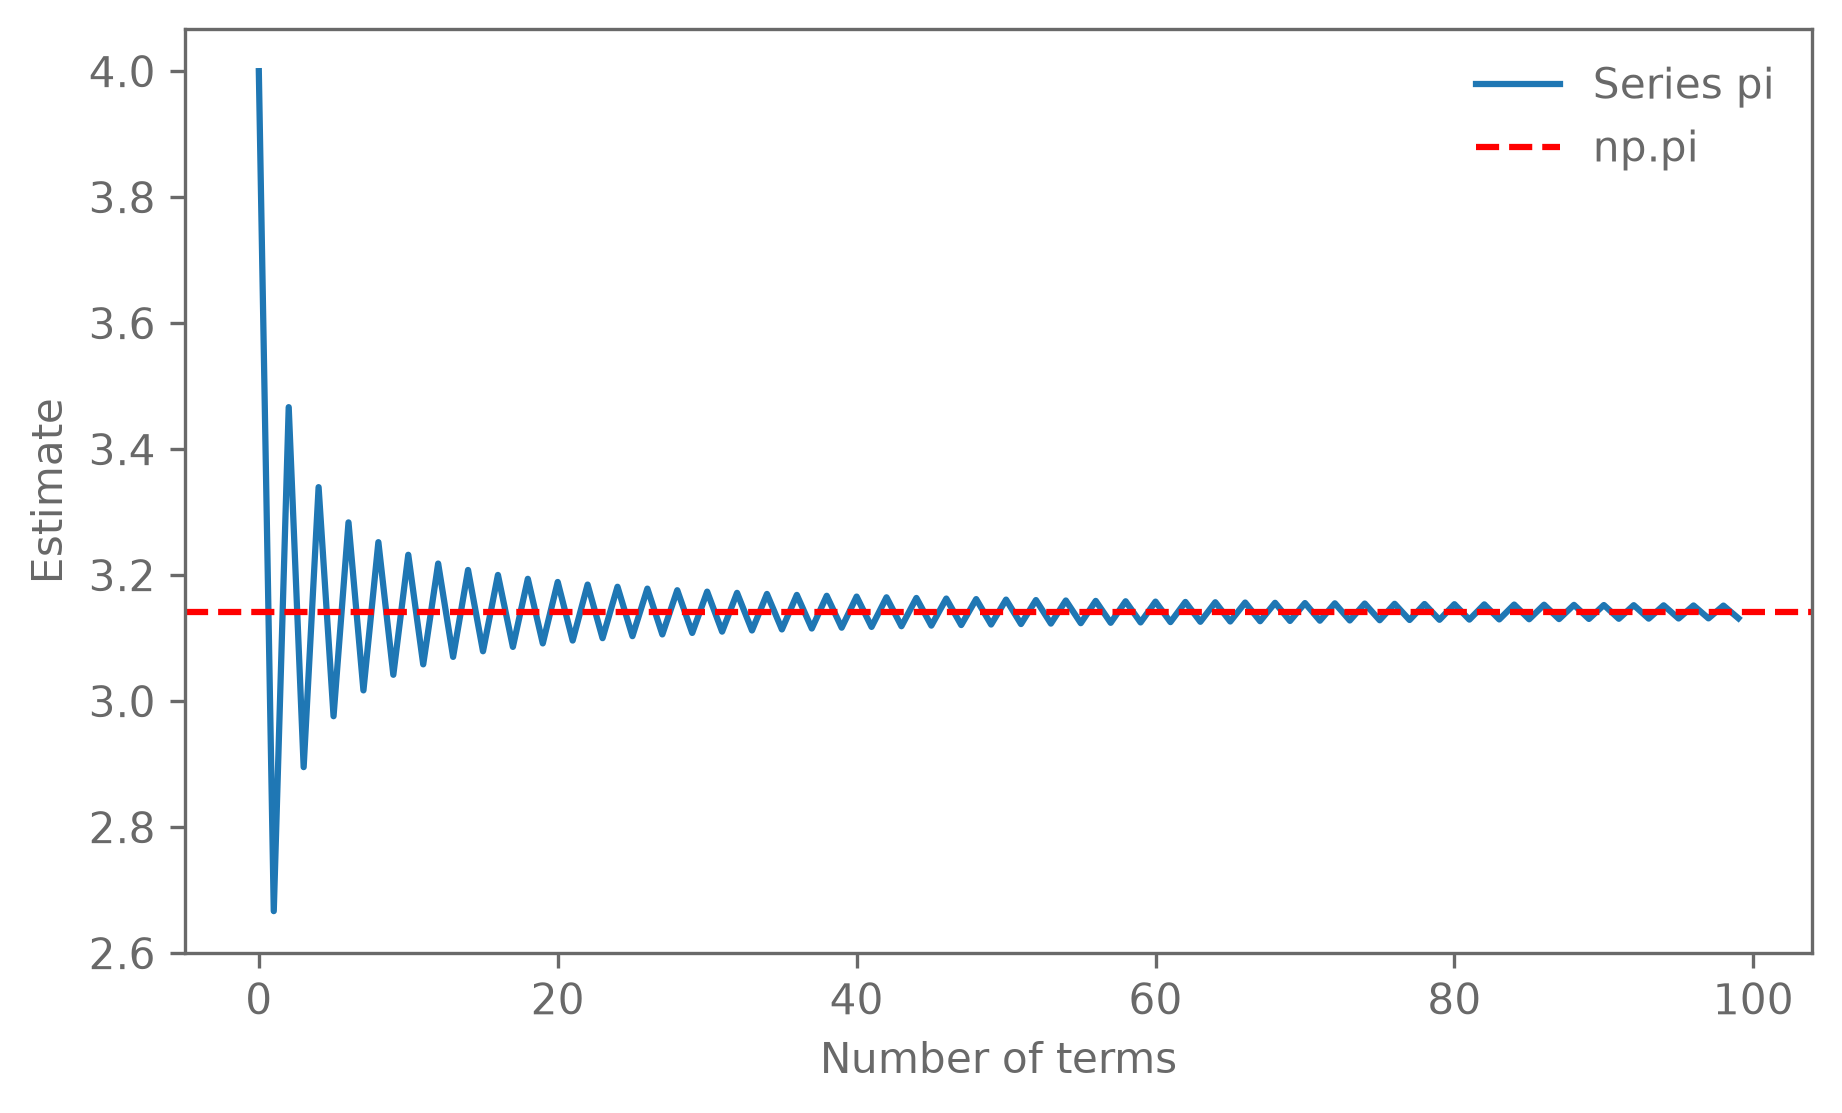

In [3]:
# series expansion
num_terms = 100
series_pi = 4 * np.cumsum([(-1)**k / (2*k + 1) for k in range(num_terms)])
plt.plot(series_pi, label='Series pi')
ax = plt.gca()
ax.axhline(np.pi, c='r', ls='--', label='np.pi')
plt.legend()
plt.xlabel("Number of terms")
plt.ylabel("Estimate")
plt.show()

# Estimate using monte carlo

This is going to use "rejection sampling." The ratio of a circle radius $r$ to a square of side $2r$ is given by:
$$ f = \frac{\pi r^2}{4r^2}.$$
If we measure the fraction of random points within the square that also fall in the circle, $n_{<r}$, we get an estimate of $f$, call this $\hat f$. This let's rearrange to find $\pi$:
$$ \hat \pi = 4 \hat f.$$

Let's visualize it, then implement it. 

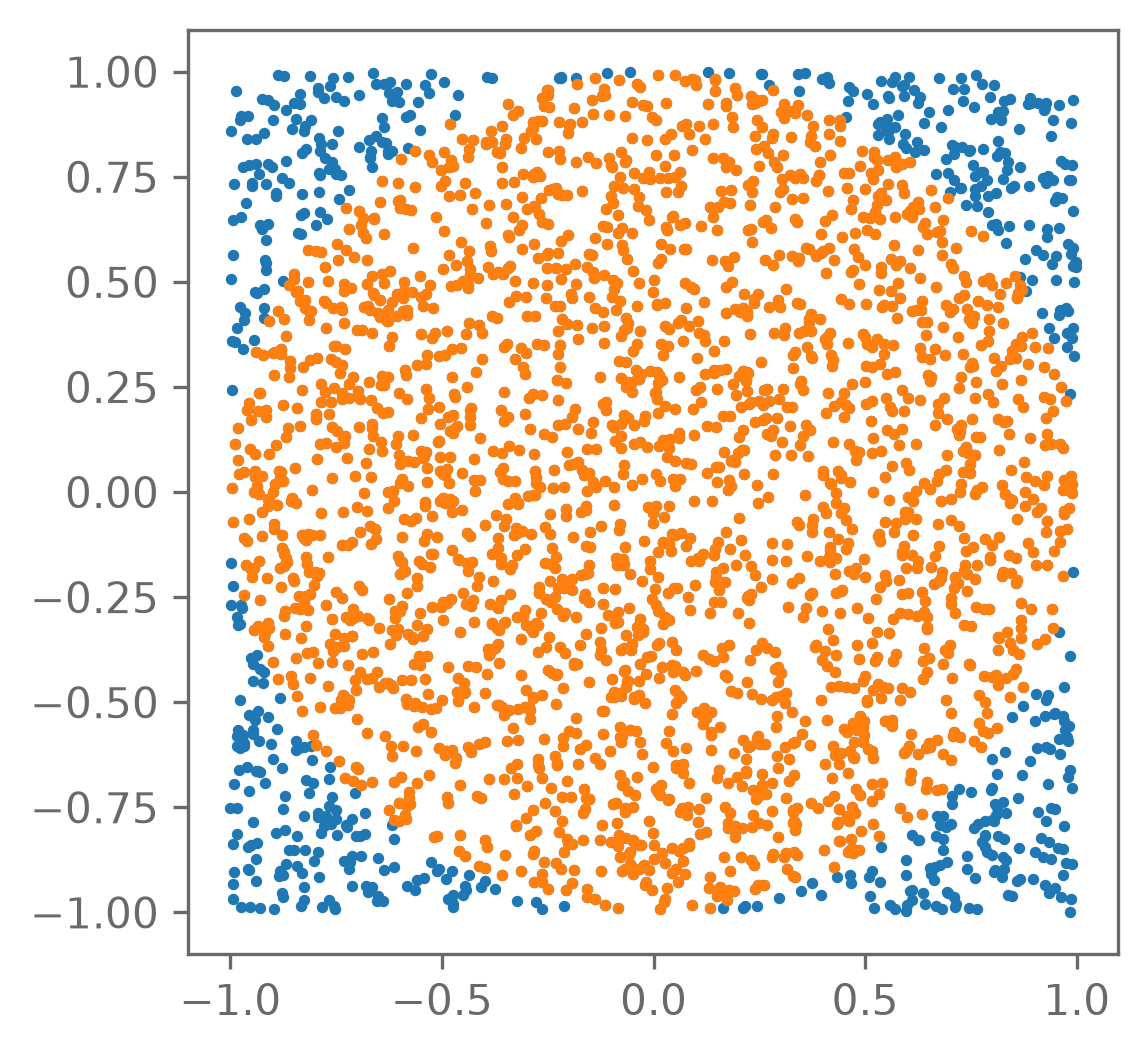

In [4]:
npts = 3000
xyvals = 2 * np.random.rand(int(npts), 2) - 1
plt.figure(figsize=(4, 4))
plt.scatter(xyvals[:, 0], xyvals[:, 1], s=3)
rvals = np.sqrt(xyvals[:, 0]**2 + xyvals[:, 1]**2)
idxs = rvals < 1
plt.scatter(xyvals[idxs, 0], xyvals[idxs, 1], s=3)
plt.show()

<>:13: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:13: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
/var/folders/6y/tmhw8hp56_3888btjkrlhh6r0000gn/T/ipykernel_59968/1410485466.py:13: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plt.ylabel("$\hat \pi - \pi$")


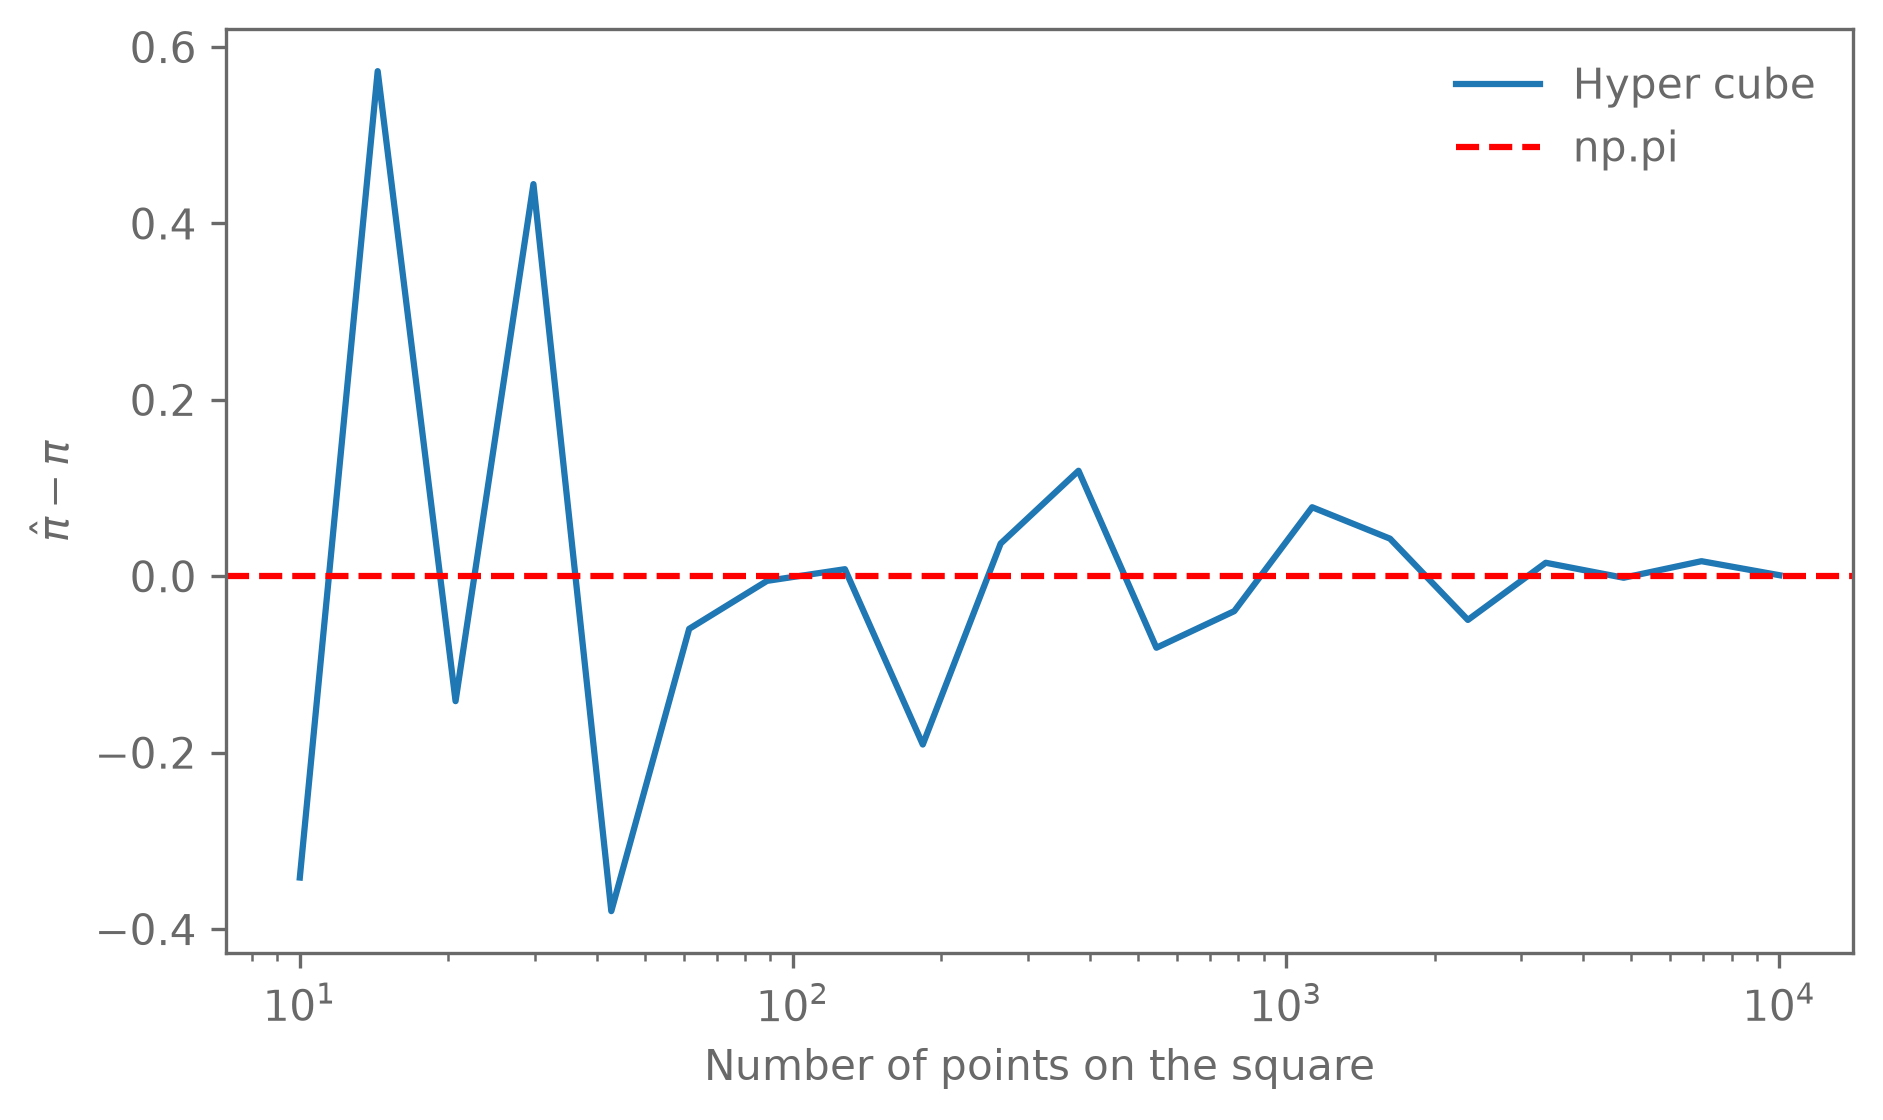

In [5]:
npoints = np.logspace(1, 4, num=20)
radius = 1
square_area = (2 * radius)**2
pi_estimates = []
for npts in npoints:
    xyvals = 2 * radius * np.random.rand(int(npts), 2) - radius # 100 different xy values
    rvals = np.sqrt(xyvals[:, 0]**2 + xyvals[:, 1]**2)
    frac = np.sum(rvals < radius) / rvals.size
    pi_estimates.append(frac * 4)
plt.plot(npoints, np.array(pi_estimates) - np.pi, label='Hyper cube')
ax = plt.gca()
ax.axhline(0, c='r', ls='--', label='np.pi')
plt.ylabel("$\hat \pi - \pi$")
plt.xlabel("Number of points on the square")
plt.xscale("log")
plt.legend()
plt.show()
plt.show()
    

# Monte carlo error

We can also estimate how the error in this estimate should scale with the number of random points we draw in the square. 

We can test this by re-running the above example many times for each choice of $n$, and taking the variance (the spread) at each value of $n$. So for $n=100$ we re-do this 1000 times with different random draws, and we look at the spread of those 1000 random draws. We then repeat for another value of $n$ and so on.

We can also estimate this analytically. We will return to this later in the course!! The distribution on the number of points in the circle is governed by a binomial distribution. For now, we can look up what the **expectation value** and the **variance** on the estimate $\hat f$ is, and we find:

$$\sigma^2_{\hat f} = \frac{f(1-f)}{n}.$$
$$\sigma^2_{\hat \pi} = \frac{16f(1-f)}{n}.$$

This $1/n$ scaling will show up all over the place. 


In [6]:
npoints = np.logspace(1, 4, num=20)
n_simulations = 1000 # repeat 1000 times
pi_estimates = np.zeros((npoints.size, n_simulations))
for nsim in range(n_simulations):
    for ii, npts in enumerate(npoints):
        xyvals = np.random.rand(int(npts), 2) # 100 different xy values
        rvals = np.sqrt(xyvals[:, 0]**2 + xyvals[:, 1]**2)
        frac = np.sum(rvals < 1) / rvals.size
        # pi_estimates.append(frac * 4)
        pi_estimates[ii, nsim] = frac*4
pi_variances = pi_estimates.var(axis=-1) # take the variance over the last axis

<>:3: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:3: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/6y/tmhw8hp56_3888btjkrlhh6r0000gn/T/ipykernel_59968/543978955.py:3: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.ylabel('$var(\\hat \pi)$')


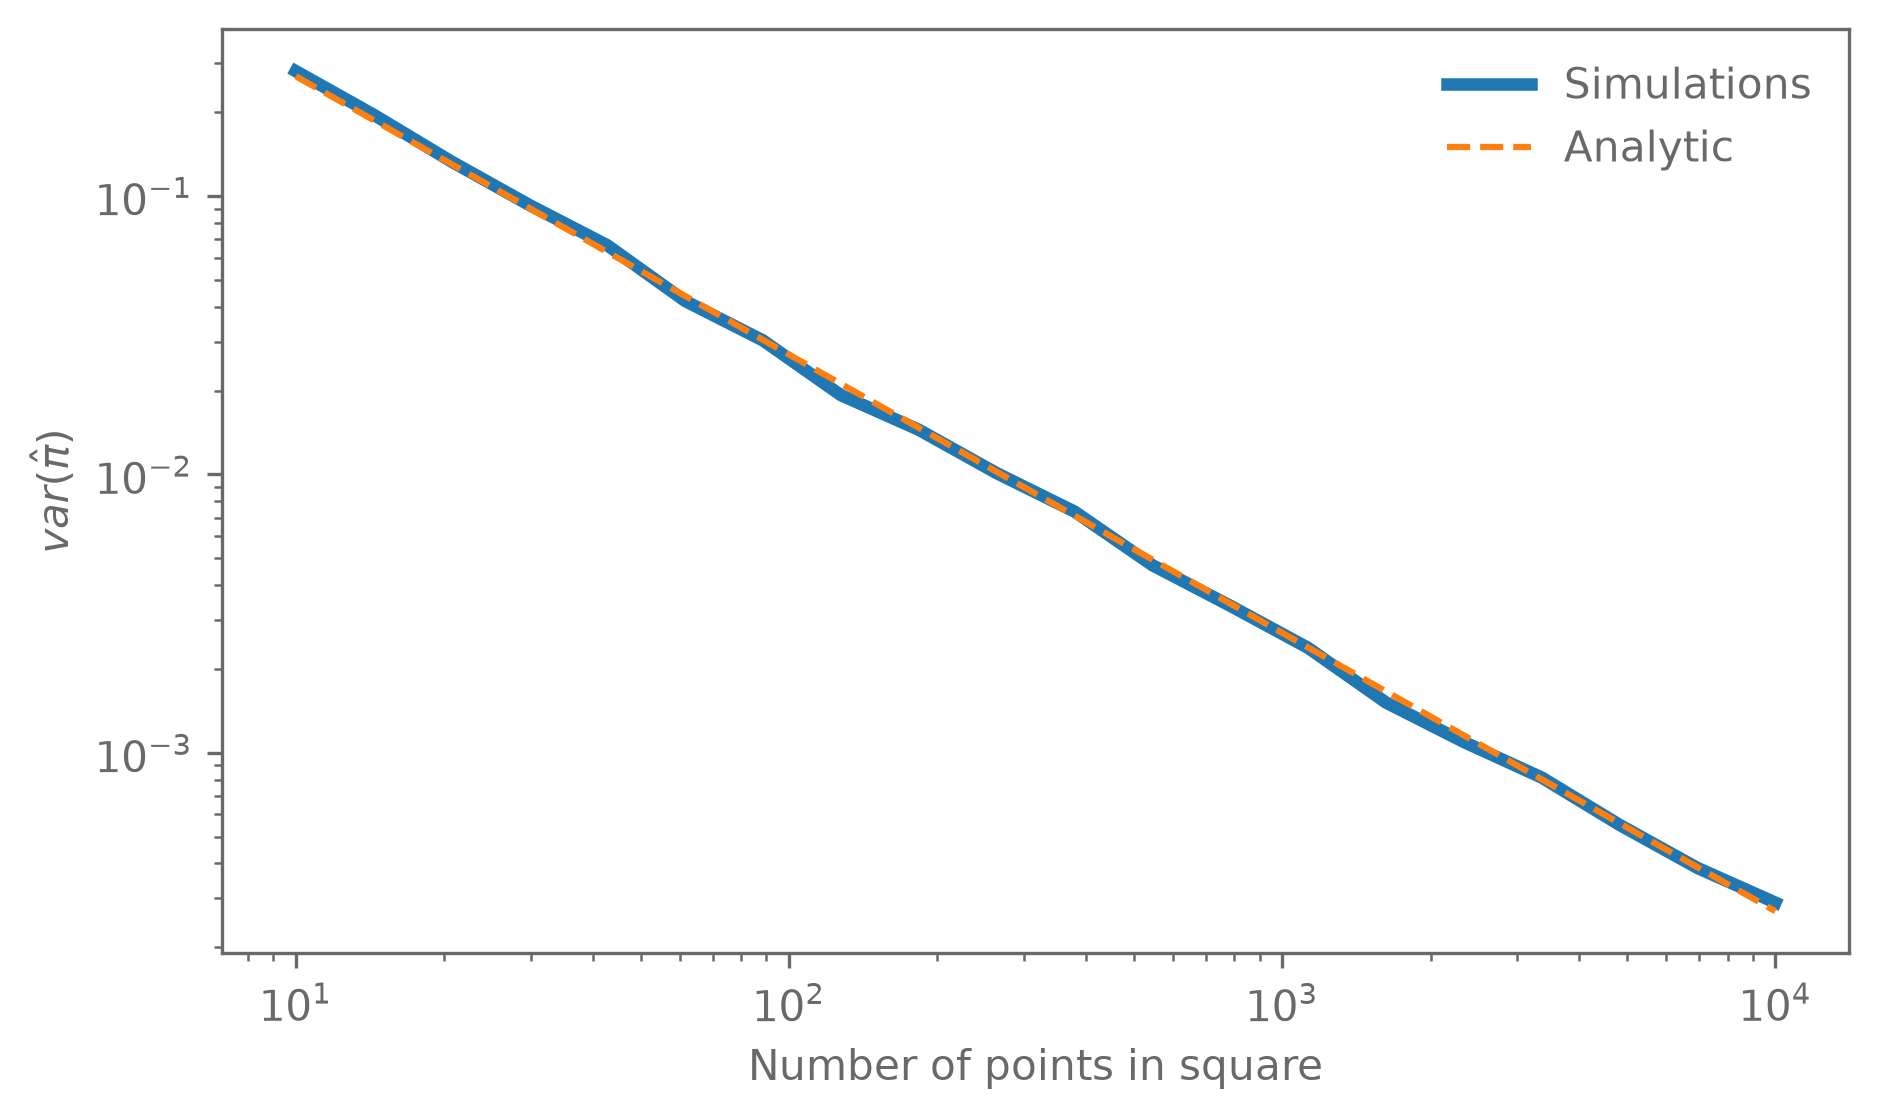

In [7]:
plt.loglog(npoints, pi_variances, label='Simulations', lw=3)
plt.plot(npoints, (16 * np.pi / 4 * ( 1 - np.pi / 4) / npoints), label='Analytic', lw=1.5, ls='--')
plt.ylabel('$var(\\hat \pi)$')
plt.xlabel('Number of points in square')
plt.legend()
plt.show()

<>:6: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:6: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
/var/folders/6y/tmhw8hp56_3888btjkrlhh6r0000gn/T/ipykernel_59968/1057918701.py:6: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plt.ylabel("$\hat \pi - \pi$")


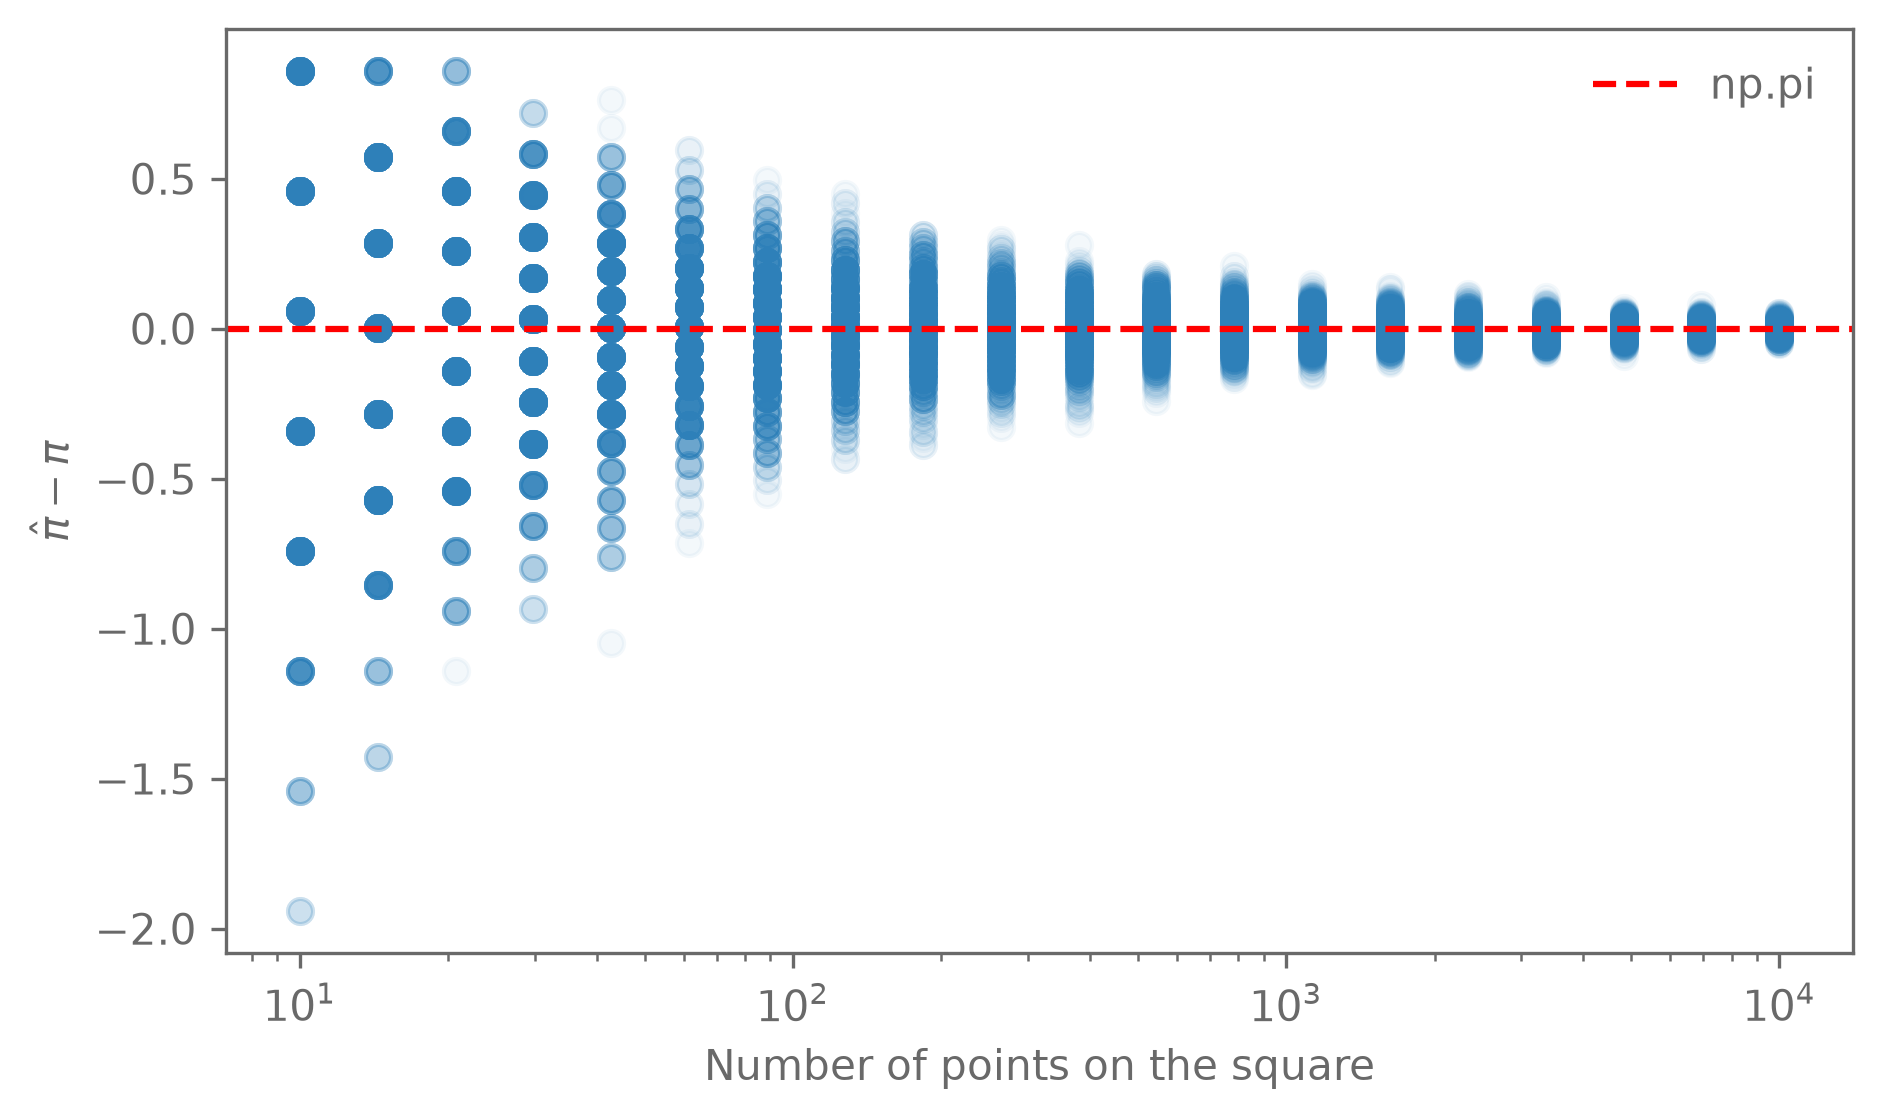

In [8]:
# remake the top plot, but over our 1000 simulations
for ii in range(n_simulations):
    plt.scatter(npoints, np.array(pi_estimates[:, ii]) - np.pi, alpha=0.05, c='C0')
ax = plt.gca()
ax.axhline(0, c='r', ls='--', label='np.pi')
plt.ylabel("$\hat \pi - \pi$")
plt.xlabel("Number of points on the square")
plt.xscale("log")
plt.legend()
plt.show()
plt.show()

# Higher dimensions

In higher dimensions we can use the formula for the area of a hypercube of dimension $d$: $2^dr^d$, and hyperball:
$$\frac{\pi^{d/2} r^d}{\Gamma(d/2 + 1)}$$ where $\Gamma$ is the typical [$\Gamma$ function](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.gamma.html) (an analytic extension of the factorial). We can once again solve for $\pi$:

$$\hat \pi = \left[\hat f \cdot 2^d \cdot \Gamma(d/2 + 1)\right]^{2/d}.$$

Doing this, we find that this works, and converges. So let's skip straight to looking at the variances again. How quickly does the error on our estimator drop as we add more points? And how does that change for each dimension?

In [9]:
def pi_estimate(frac, ndim):
    return (frac * 2**ndim * ss.gamma(ndim / 2 + 1))**(2/ndim)

def get_fraction(npoints, ndim):
    cube_coords = np.random.rand(npoints, ndim)
    rvals = np.sqrt(np.sum(cube_coords * cube_coords, axis=1))
    frac = np.sum(rvals < 1) / npoints
    return frac

ndims = np.array([2, 3, 4, 5, 6, 7, 8])
npoints = np.logspace(1, 3, num=10)
nrealizations = 100
results = np.zeros((npoints.size, ndims.size, nrealizations))

for ii, npts in enumerate(npoints):
    for jj, nd in enumerate(ndims):
        for kk in range(nrealizations):
            results[ii, jj, kk] = pi_estimate(get_fraction(int(npts), nd), nd)
results_std = results.std(axis=-1)
bias = results.mean(axis=-1) - np.pi

In [10]:
print(results_std.shape)

(10, 7)


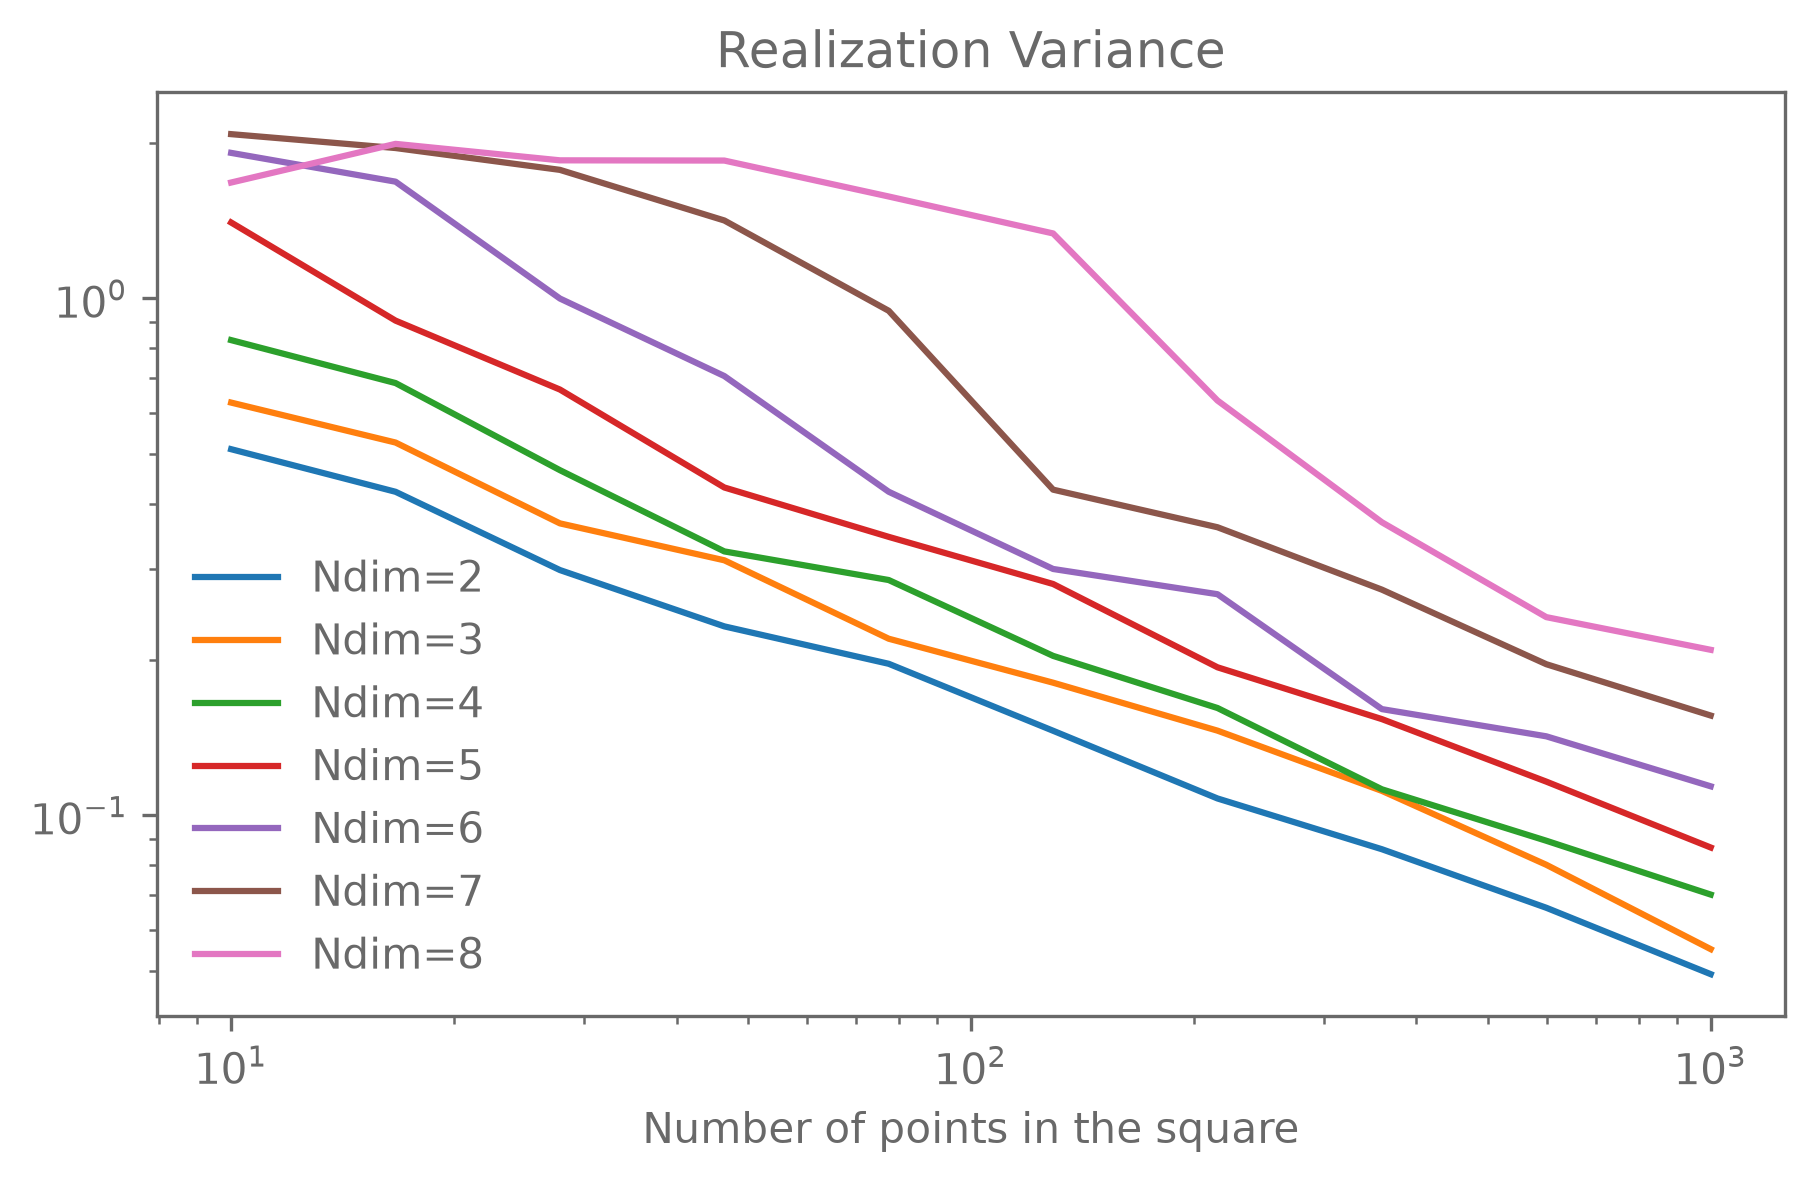

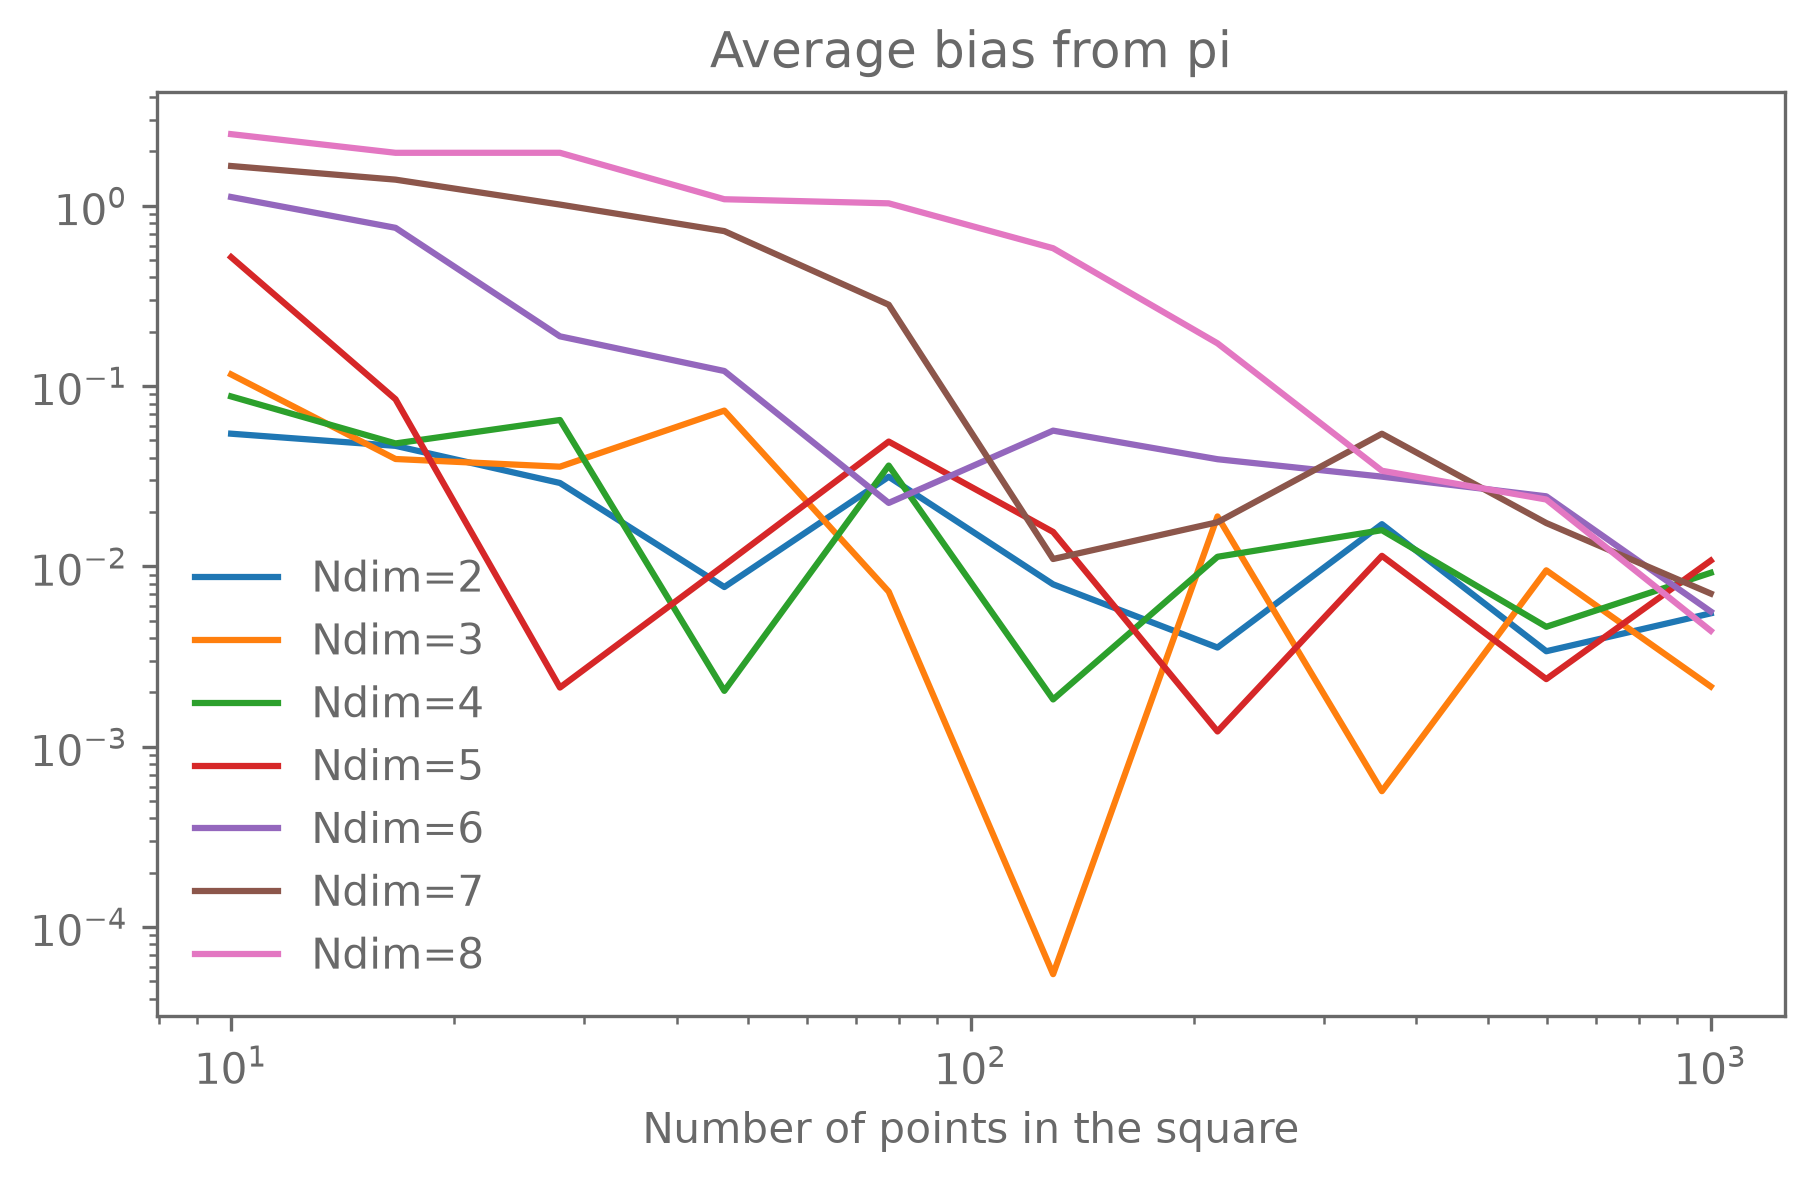

In [11]:
plt.title('Realization Variance')
for ii in range(ndims.size):
    plt.loglog(npoints, results_std[:, ii], label=f'Ndim={ndims[ii]}')
plt.xlabel("Number of points in the square")
plt.legend()
plt.show()

plt.title('Average bias from pi')
for ii in range(ndims.size):
    plt.loglog(npoints, np.abs(bias[:, ii]), label=f'Ndim={ndims[ii]}')
plt.xlabel("Number of points in the square")
plt.legend()
plt.show()

Text(0, 0.5, '$\\sigma$')

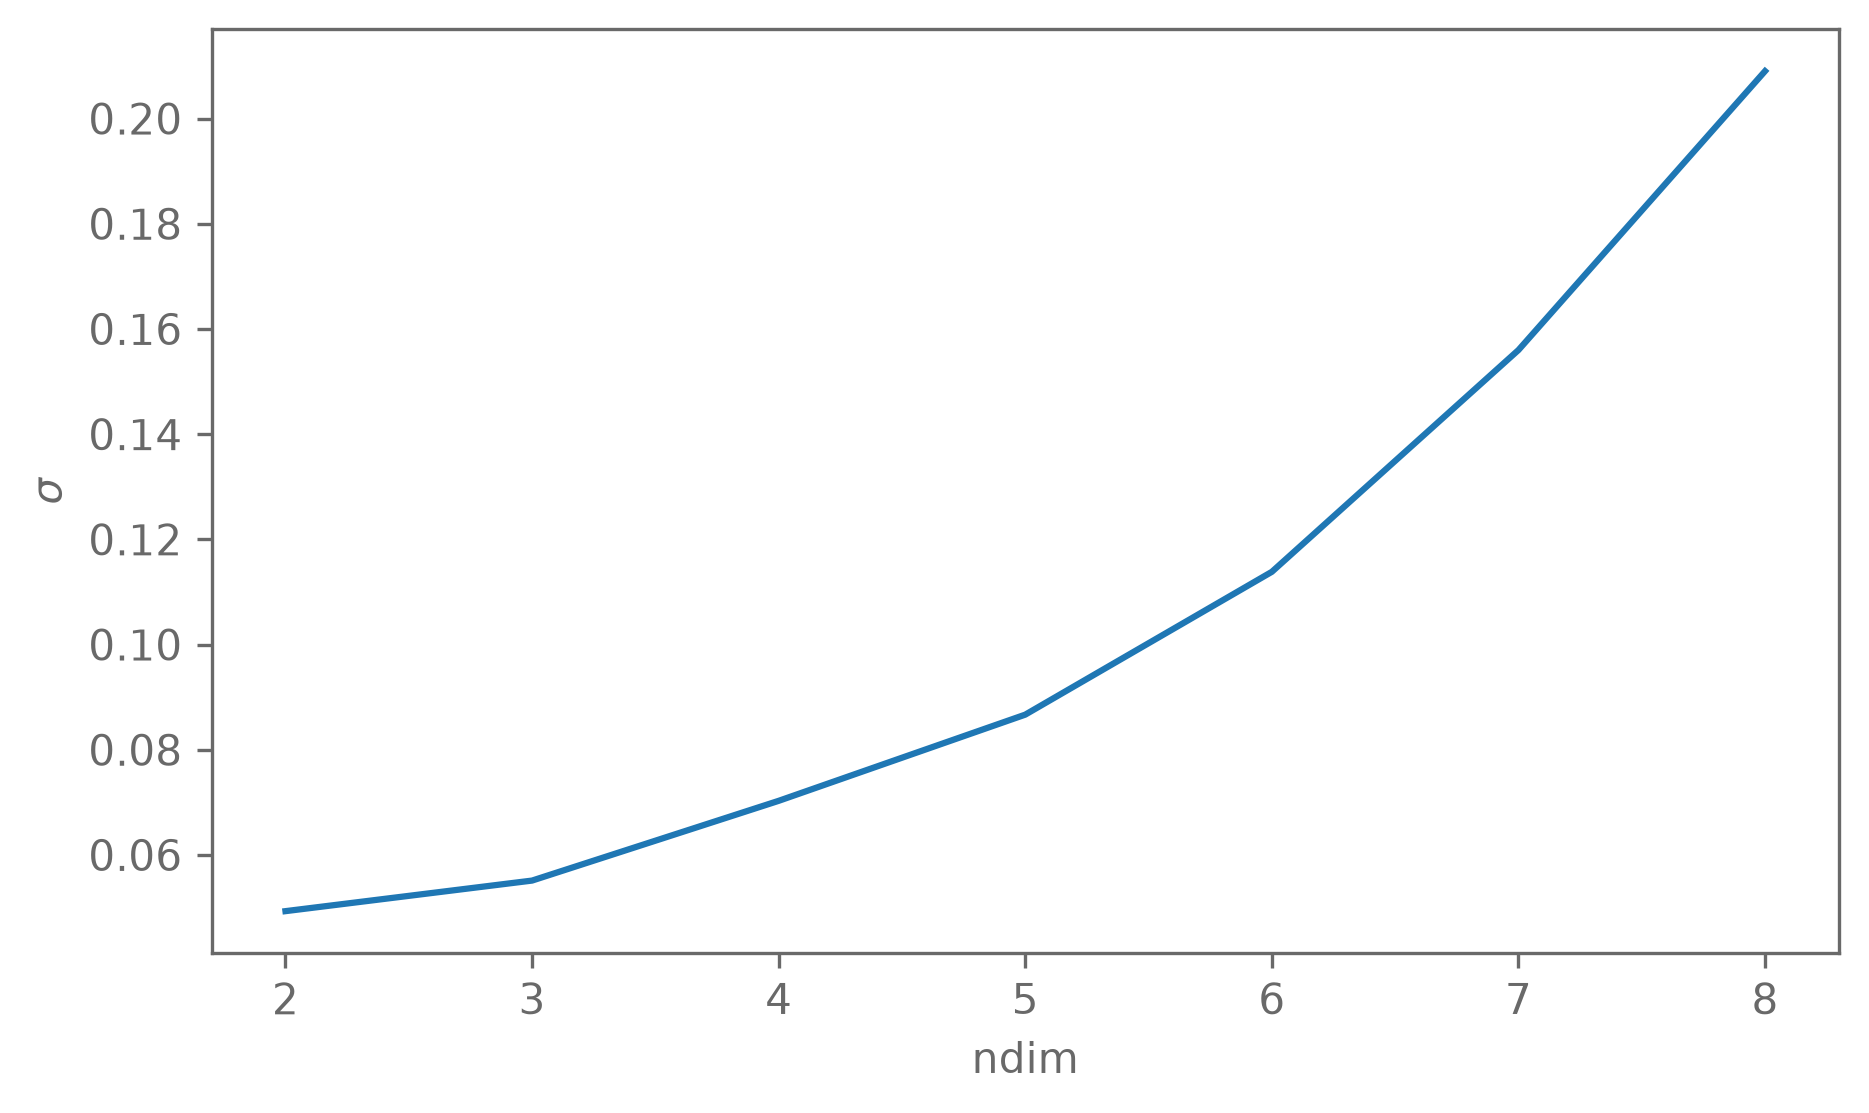

In [12]:
# How does this variance scale with dimension, once we are at
# the highest number of points in the hypercube

plt.plot(ndims, results_std[-1, :])
plt.xlabel("ndim")
plt.ylabel("$\\sigma$")